# 1. Importing Libraries

In [65]:
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML and modeling
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Suppress warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 2. Loading the Dataset

In [66]:
# ============================================================================
# 2. DATA LOADING AND INITIAL INSPECTION
# ============================================================================
print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

# Load dataset
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values:\n{data.isnull().sum()}")

# Display sample
print("\nFirst 5 rows:")
print(data.head())

LOADING DATASET
Dataset shape: (123984, 20)

Columns: ['report_date', 'category', 'item_raw', 'item_standard', 'origin_type', 'price_type', 'market', 'unit_raw', 'unit_std', 'currency', 'prev_window_label', 'price_prev', 'today_label', 'price_today', 'special_notes', 'source_doc_id', 'source_doc_date', 'source_url', 'ingested_at', 'row_id']

Data types:
report_date           object
category              object
item_raw              object
item_standard         object
origin_type           object
price_type            object
market                object
unit_raw              object
unit_std              object
currency              object
prev_window_label     object
price_prev           float64
today_label           object
price_today          float64
special_notes         object
source_doc_id         object
source_doc_date       object
source_url            object
ingested_at           object
row_id                object
dtype: object

Missing values:
report_date               0
categ

# 3. Data cleaning and preprocessing

In [67]:
# ============================================================================
# 3. DATA CLEANING AND PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 80)

# Create a clean copy
df = data.copy()

# 3.1 Convert report_date to datetime
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%Y', errors='coerce')
print(f"Date range: {df['report_date'].min()} to {df['report_date'].max()}")

# 3.2 Handle missing values - only for special_notes
df['special_notes'] = df['special_notes'].fillna('')

# 3.3 Standardize units - CRITICAL STEP
# Create conversion dictionary based on typical conversions
unit_conversion = {
    'Rs./Kg': 1.0,
    'Rs./Ltr': 1.0,  # Assuming 1 liter ~ 1 kg for conversion purposes
    'Rs./Nut': 1.0,  # Need actual conversion factor for nuts
    'Rs./Each': 1.0  # Need actual conversion factor for pieces
}
# Note: In production, you need actual conversion factors for Each, Nut, Ltr to Kg

# 3.4 Filter for Component 1 categories only
component1_categories = ['Vegetables', 'Fruits', 'Rice']
df = df[df['category'].isin(component1_categories)].copy()
print(f"Data after filtering for Component 1 categories: {df.shape}")

# 3.5 Filter for required items only
required_items = {
    'Vegetables': ['Beans', 'Carrot', 'Cabbage', 'Tomato', 'Brinjal', 'Pumpkin', 
                   'Snake gourd', 'Green Chilli', 'Lime'],
    'Fruits': ['Banana', 'Papaw', 'Pineapple', 'Apple', 'Orange'],
    'Rice': ['Samba', 'Nadu', 'Kekulu', 'Ponni Samba']
}

# Filter items
valid_items = []
for category, items in required_items.items():
    for item in items:
        # Check if item exists in item_standard
        if item in df['item_standard'].unique():
            valid_items.append(item)

df = df[df['item_standard'].isin(valid_items)].copy()
print(f"Data after filtering for required items: {df.shape}")


DATA CLEANING AND PREPROCESSING
Date range: 2017-09-12 00:00:00 to 2025-10-11 00:00:00
Data after filtering for Component 1 categories: (61992, 20)
Data after filtering for required items: (61992, 20)


# 4. EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS

Price statistics by category:
              count        mean         std     min       25%      50%  \
category                                                                 
Fruits      14760.0  300.688913  115.787956  100.01  199.7850  300.530   
Rice        20664.0  300.056114  115.495215  100.01  199.4975  301.620   
Vegetables  26568.0  300.211717  115.230345  100.02  200.5650  300.475   

                 75%     max  
category                      
Fruits      400.8350  499.98  
Rice        399.2925  499.99  
Vegetables  399.4725  499.98  


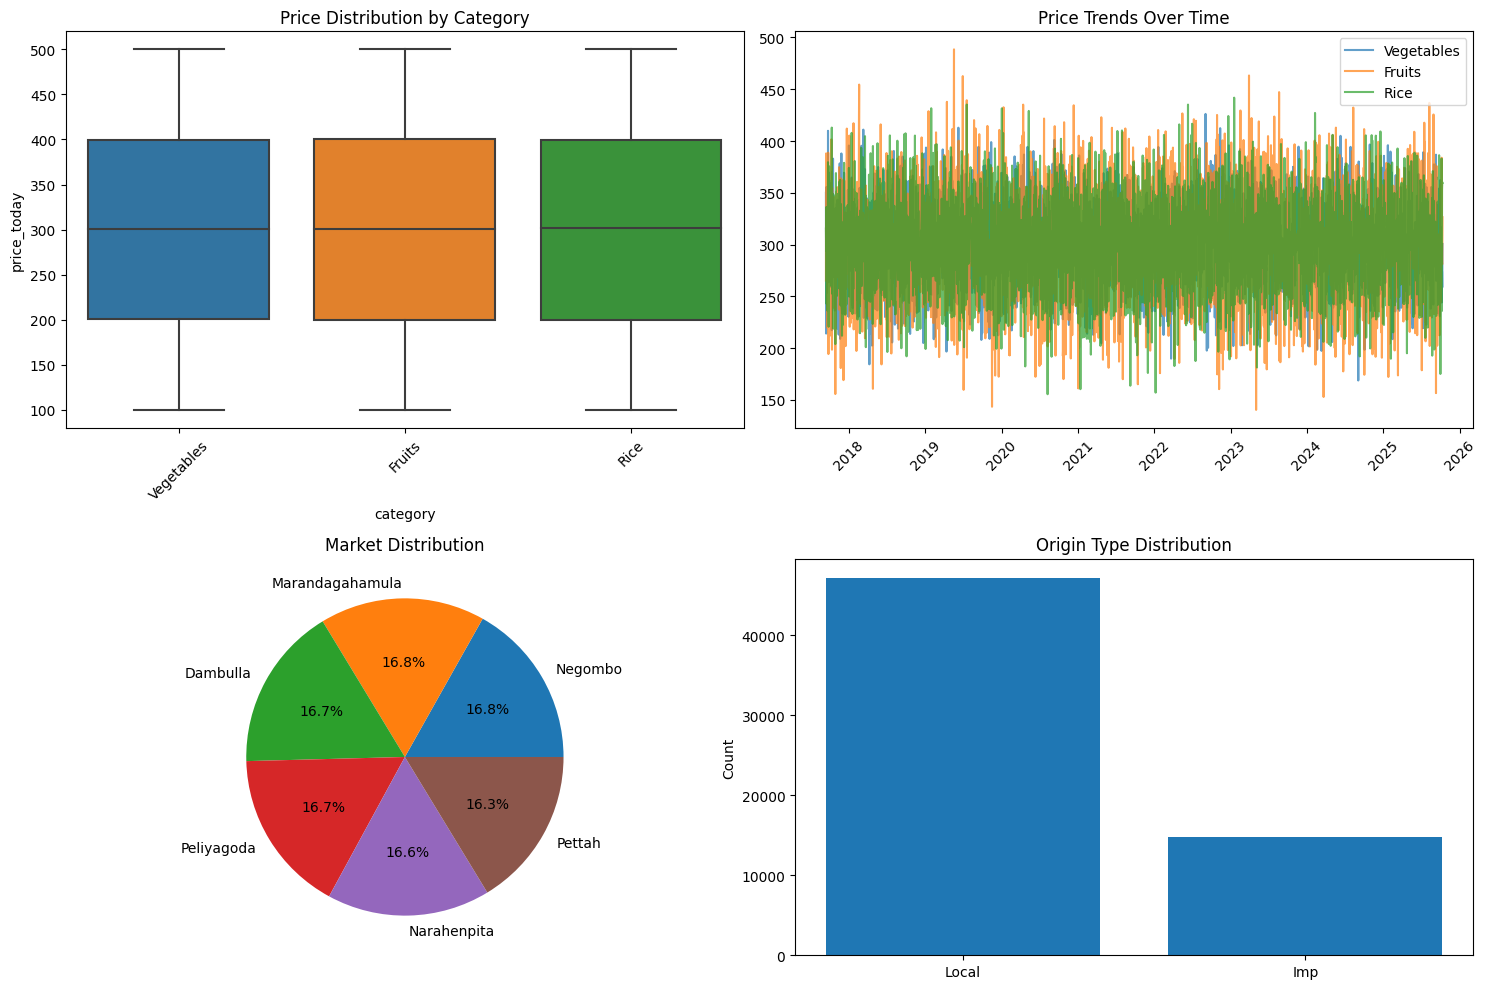

In [68]:
# ============================================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# 4.1 Basic statistics
print("\nPrice statistics by category:")
print(df.groupby('category')['price_today'].describe())

# 4.2 Visualizations
plt.figure(figsize=(15, 10))

# Price distribution by category
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='category', y='price_today')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45)

# Price trends over time
plt.subplot(2, 2, 2)
for category in df['category'].unique():
    category_data = df[df['category'] == category]
    avg_price = category_data.groupby('report_date')['price_today'].mean()
    plt.plot(avg_price.index, avg_price.values, label=category, alpha=0.7)
plt.title('Price Trends Over Time')
plt.legend()
plt.xticks(rotation=45)

# Market distribution
plt.subplot(2, 2, 3)
market_counts = df['market'].value_counts()
plt.pie(market_counts.values, labels=market_counts.index, autopct='%1.1f%%')
plt.title('Market Distribution')

# Origin type distribution
plt.subplot(2, 2, 4)
origin_counts = df['origin_type'].value_counts()
plt.bar(origin_counts.index, origin_counts.values)
plt.title('Origin Type Distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 5. FEATURE ENGINEERING

In [69]:
# ============================================================================
# 5. FEATURE ENGINEERING (CORRECTED VERSION)
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Sort by date and item for proper time-series calculations
df = df.sort_values(['item_standard', 'market', 'report_date']).reset_index(drop=True)

# Create time-based features
df['day'] = df['report_date'].dt.day
df['month'] = df['report_date'].dt.month
df['year'] = df['report_date'].dt.year
df['week'] = df['report_date'].dt.isocalendar().week
df['dayofweek'] = df['report_date'].dt.dayofweek
df['quarter'] = df['report_date'].dt.quarter

# Create unique identifier for time-series groups
df['ts_group'] = df['item_standard'] + '_' + df['market'] + '_' + df['price_type']

# CRITICAL: Use price_prev for lag features, NOT price_today (to avoid data leakage)
def create_time_series_features(group):
    """Create time-series features for each item-market combination"""
    group = group.sort_values('report_date')
    
    # Lag features (using price_prev which is already lagged)
    group['lag_1'] = group['price_prev'].shift(1)
    group['lag_2'] = group['price_prev'].shift(2)
    group['lag_3'] = group['price_prev'].shift(3)
    
    # Rolling statistics (using price_prev)
    group['rolling_mean_3'] = group['price_prev'].rolling(window=3, min_periods=1).mean()
    group['rolling_mean_7'] = group['price_prev'].rolling(window=7, min_periods=1).mean()
    group['rolling_std_7'] = group['price_prev'].rolling(window=7, min_periods=1).std()
    group['rolling_min_7'] = group['price_prev'].rolling(window=7, min_periods=1).min()
    group['rolling_max_7'] = group['price_prev'].rolling(window=7, min_periods=1).max()
    
    # Momentum features
    group['momentum_3'] = group['price_prev'] - group['price_prev'].shift(3)
    group['momentum_7'] = group['price_prev'] - group['price_prev'].shift(7)
    
    # Volatility features
    group['volatility_7'] = group['price_prev'].rolling(window=7, min_periods=1).std() / \
                           group['price_prev'].rolling(window=7, min_periods=1).mean()
    
    # Price change features
    group['price_change_1'] = group['price_prev'].pct_change(periods=1)
    group['price_change_3'] = group['price_prev'].pct_change(periods=3)
    
    # Seasonal features
    group['month_sin'] = np.sin(2 * np.pi * group['month'] / 12)
    group['month_cos'] = np.cos(2 * np.pi * group['month'] / 12)
    
    # Day of week cyclical encoding
    group['dayofweek_sin'] = np.sin(2 * np.pi * group['dayofweek'] / 7)
    group['dayofweek_cos'] = np.cos(2 * np.pi * group['dayofweek'] / 7)
    
    return group

# Apply feature engineering
print("Creating time-series features...")
df = df.groupby('ts_group', group_keys=False).apply(create_time_series_features)

# Create interaction features
df['is_retail'] = (df['price_type'] == 'Retail').astype(int)
df['is_imported'] = (df['origin_type'] == 'Imp').astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Special notes feature
df['has_special_note'] = (df['special_notes'] != '').astype(int)
df['low_supply_note'] = df['special_notes'].str.contains('low supply', case=False).astype(int)

# Drop rows with NaN in critical features
df = df.dropna(subset=['lag_1', 'rolling_mean_7', 'price_today']).copy()
print(f"Data shape after feature engineering: {df.shape}")


FEATURE ENGINEERING
Creating time-series features...
Data shape after feature engineering: (61776, 49)


# 6. ENCODING CATEGORICAL VARIABLES

In [70]:
# ============================================================================
# 6. ENCODING CATEGORICAL VARIABLES
# ============================================================================
print("\n" + "=" * 80)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 80)

# Initialize encoders
encoders = {}

# Categorical columns to encode
cat_cols = ['market', 'item_standard', 'category', 'origin_type', 'price_type']

for col in cat_cols:
    encoder = LabelEncoder()
    df[f'{col}_encoded'] = encoder.fit_transform(df[col])
    encoders[col] = encoder
    print(f"{col}: {len(encoder.classes_)} unique values")

# Save encoders
joblib.dump(encoders, '/kaggle/working/encoders.pkl')
print("\nEncoders saved to /kaggle/working/encoders.pkl")


ENCODING CATEGORICAL VARIABLES
market: 6 unique values
item_standard: 18 unique values
category: 3 unique values
origin_type: 2 unique values
price_type: 2 unique values

Encoders saved to /kaggle/working/encoders.pkl


# 7. PREPARE FEATURES AND TARGET FOR MODELING

In [71]:
# ============================================================================
# 7. PREPARE FEATURES AND TARGET FOR MODELING
# ============================================================================
print("\n" + "=" * 80)
print("PREPARING FEATURES AND TARGET")
print("=" * 80)

# Define features (excluding those that cause data leakage)
features = [
    # Time features
    'day', 'month', 'year', 'week', 'dayofweek', 'quarter',
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    
    # Encoded categorical features
    'market_encoded', 'item_standard_encoded', 'category_encoded',
    'origin_type_encoded', 'price_type_encoded',
    
    # Time-series features (using price_prev, not price_today)
    'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7',
    'rolling_min_7', 'rolling_max_7',
    'momentum_3', 'momentum_7', 'volatility_7',
    'price_change_1', 'price_change_3',
    
    # Interaction features
    'is_retail', 'is_imported', 'is_weekend',
    'has_special_note', 'low_supply_note'
]

# Target variable
target = 'price_today'

# Create feature matrix and target vector
X = df[features].copy()
y = df[target].copy()
dates = df['report_date'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


PREPARING FEATURES AND TARGET
Feature matrix shape: (61776, 33)
Target vector shape: (61776,)


# 8. TIME-SERIES TRAIN-TEST SPLIT

In [72]:
# ============================================================================
# 8. TIME-SERIES TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "=" * 80)
print("TIME-SERIES TRAIN-TEST SPLIT")
print("=" * 80)

# Sort by date
sorted_idx = np.argsort(dates)
X_sorted = X.iloc[sorted_idx]
y_sorted = y.iloc[sorted_idx]
dates_sorted = dates.iloc[sorted_idx]

# Split chronologically (80% train, 20% test)
split_idx = int(0.8 * len(X_sorted))
X_train = X_sorted.iloc[:split_idx]
X_test = X_sorted.iloc[split_idx:]
y_train = y_sorted.iloc[:split_idx]
y_test = y_sorted.iloc[split_idx:]
train_dates = dates_sorted.iloc[:split_idx]
test_dates = dates_sorted.iloc[split_idx:]

print(f"Training set: {X_train.shape} ({train_dates.min()} to {train_dates.max()})")
print(f"Testing set: {X_test.shape} ({test_dates.min()} to {test_dates.max()})")


TIME-SERIES TRAIN-TEST SPLIT
Training set: (49420, 33) (2017-09-13 00:00:00 to 2024-03-02 00:00:00)
Testing set: (12356, 33) (2024-03-02 00:00:00 to 2025-10-11 00:00:00)


# 9. ENHANCED MODELING APPROACH

In [73]:
# ============================================================================
# ENHANCED MODELING APPROACH
# ============================================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. DATA ENHANCEMENT
# ============================================================================
print("=" * 80)
print("ENHANCING DATA FOR BETTER PERFORMANCE")
print("=" * 80)

# Assuming df is your preprocessed dataframe
# Add more sophisticated features:

# A. Price normalization by item (crucial for different price ranges)
item_price_stats = df.groupby('item_standard')['price_today'].agg(['mean', 'std']).to_dict('index')
df['price_norm'] = df.apply(
    lambda row: (row['price_today'] - item_price_stats[row['item_standard']]['mean']) / 
                max(item_price_stats[row['item_standard']]['std'], 1),
    axis=1
)

# B. Market-specific features
market_item_stats = df.groupby(['market', 'item_standard'])['price_today'].agg(['mean', 'std']).reset_index()
market_item_stats.columns = ['market', 'item_standard', 'market_item_mean', 'market_item_std']
df = df.merge(market_item_stats, on=['market', 'item_standard'], how='left')

# C. More time-based features
df['day_of_year'] = df['report_date'].dt.dayofyear
df['week_of_year'] = df['report_date'].dt.isocalendar().week
df['is_month_start'] = df['report_date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['report_date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['report_date'].dt.is_quarter_start.astype(int)
df['is_quarter_end'] = df['report_date'].dt.is_quarter_end.astype(int)

# D. Cyclical encoding for better seasonality
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# E. Lag features with different windows
for lag in [1, 2, 3, 5, 7, 14, 30]:
    df[f'price_lag_{lag}'] = df.groupby('ts_group')['price_today'].shift(lag)

# F. Rolling statistics with different windows
windows = [3, 7, 14, 30]
for window in windows:
    df[f'rolling_mean_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df[f'rolling_std_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )
    df[f'rolling_min_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).min()
    )
    df[f'rolling_max_{window}'] = df.groupby('ts_group')['price_today'].transform(
        lambda x: x.rolling(window=window, min_periods=1).max()
    )

# G. Price momentum and change features
for period in [1, 3, 7, 14]:
    df[f'price_change_{period}'] = df.groupby('ts_group')['price_today'].pct_change(periods=period)
    df[f'momentum_{period}'] = df.groupby('ts_group')['price_today'].diff(periods=period)

# H. Volatility features
df['volatility_7'] = df['rolling_std_7'] / df['rolling_mean_7']
df['volatility_14'] = df['rolling_std_14'] / df['rolling_mean_14']

# I. Support/resistance levels
df['support_level'] = df.groupby('ts_group')['price_today'].transform(
    lambda x: x.rolling(window=14, min_periods=1).quantile(0.25)
)
df['resistance_level'] = df.groupby('ts_group')['price_today'].transform(
    lambda x: x.rolling(window=14, min_periods=1).quantile(0.75)
)

# J. Price position in range
df['price_position'] = (df['price_today'] - df['support_level']) / \
                       (df['resistance_level'] - df['support_level'] + 1e-10)

# ============================================================================
# 2. ADVANCED FEATURE SELECTION
# ============================================================================
print("\nSelecting optimal features...")

# Define comprehensive feature set
advanced_features = [
    # Basic features
    'market_encoded', 'item_standard_encoded', 'category_encoded',
    'origin_type_encoded', 'price_type_encoded',
    
    # Time features
    'day', 'month', 'year', 'week', 'dayofweek', 'quarter',
    'day_of_year', 'week_of_year',
    'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
    
    # Cyclical features
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    'day_of_year_sin', 'day_of_year_cos', 'week_sin', 'week_cos',
    
    # Lag features
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_7',
    
    # Rolling statistics
    'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14',
    'rolling_std_7', 'rolling_std_14',
    'rolling_min_7', 'rolling_max_7',
    
    # Momentum and change
    'price_change_1', 'price_change_7',
    'momentum_1', 'momentum_7',
    
    # Volatility
    'volatility_7', 'volatility_14',
    
    # Support/resistance
    'support_level', 'resistance_level', 'price_position',
    
    # Interaction features
    'is_retail', 'is_imported', 'is_weekend',
    
    # Market-item specific
    'market_item_mean', 'market_item_std',
    
    # Normalized price
    'price_norm'
]

# Remove any features with too many missing values
features_to_use = []
for feature in advanced_features:
    if feature in df.columns:
        missing_pct = df[feature].isnull().mean()
        if missing_pct < 0.3:  # Keep if <30% missing
            features_to_use.append(feature)
            df[feature] = df[feature].fillna(df[feature].median())
        else:
            print(f"Dropping {feature}: {missing_pct:.1%} missing")

print(f"\nUsing {len(features_to_use)} features")

# ============================================================================
# 3. ADVANCED MODEL TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("ADVANCED MODEL TRAINING")
print("=" * 80)

# Prepare data
X = df[features_to_use].copy()
y = df['price_today'].copy()

# Time-based split
sorted_idx = np.argsort(df['report_date'])
split_idx = int(0.8 * len(X))

X_train = X.iloc[sorted_idx[:split_idx]]
X_test = X.iloc[sorted_idx[split_idx:]]
y_train = y.iloc[sorted_idx[:split_idx]]
y_test = y.iloc[sorted_idx[split_idx:]]

print(f"Training: {X_train.shape}, Testing: {X_test.shape}")



ENHANCING DATA FOR BETTER PERFORMANCE

Selecting optimal features...

Using 51 features

ADVANCED MODEL TRAINING
Training: (49420, 51), Testing: (12356, 51)


# 10. LIGHTGBM MODEL TRAINING WITH CROSS-VALIDATION

In [74]:
# ============================================================================
# 9. LIGHTGBM MODEL TRAINING WITH CROSS-VALIDATION
# ============================================================================

print("\n" + "=" * 80)
print("LIGHTGBM MODEL TRAINING")
print("=" * 80)

optimized_params = [
    {
        'name': 'Conservative',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'min_data_in_leaf': 20,
            'min_sum_hessian_in_leaf': 0.001,
            'lambda_l1': 0.1,
            'lambda_l2': 0.1,
            'verbose': -1,
            'random_state': 42
        }
    },
    {
        'name': 'Balanced',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 63,
            'learning_rate': 0.1,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'min_data_in_leaf': 10,
            'min_sum_hessian_in_leaf': 0.01,
            'lambda_l1': 0.01,
            'lambda_l2': 0.1,
            'verbose': -1,
            'random_state': 42
        }
    },
    {
        'name': 'Aggressive',
        'params': {
            'objective': 'regression',
            'metric': 'mae',
            'boosting_type': 'gbdt',
            'num_leaves': 127,
            'learning_rate': 0.2,
            'feature_fraction': 0.95,
            'bagging_fraction': 0.9,
            'bagging_freq': 3,
            'min_data_in_leaf': 5,
            'min_sum_hessian_in_leaf': 0.1,
            'lambda_l1': 0.001,
            'lambda_l2': 0.01,
            'verbose': -1,
            'random_state': 42
        }
    }
]

# ============================================================================
# 5. ENSEMBLE MODELING
# ============================================================================
print("\nTraining ensemble of models...")

models = {}
predictions = {}

for config in optimized_params:
    print(f"\nTraining {config['name']} model...")
    
    # Create datasets
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    # Train model
    model = lgb.train(
        config['params'],
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, valid_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100, show_stdv=True)
        ]
    )
    
    # Make predictions
    pred = model.predict(X_test, num_iteration=model.best_iteration)
    
    # Store
    models[config['name']] = model
    predictions[config['name']] = pred
    
    # Evaluate
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred) * 100
    
    print(f"{config['name']} Model Performance:")
    print(f"  MAE: {mae:.2f} ({mae/300*100:.1f}% of mean)")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")


LIGHTGBM MODEL TRAINING

Training ensemble of models...

Training Conservative model...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.884	valid's l1: 1.89955
[200]	train's l1: 1.19598	valid's l1: 1.2404
[300]	train's l1: 0.983273	valid's l1: 1.04397
[400]	train's l1: 0.864267	valid's l1: 0.938324
[500]	train's l1: 0.785076	valid's l1: 0.869863
[600]	train's l1: 0.726028	valid's l1: 0.819836
[700]	train's l1: 0.684607	valid's l1: 0.789583
[800]	train's l1: 0.651201	valid's l1: 0.767726
[900]	train's l1: 0.623431	valid's l1: 0.751372
[1000]	train's l1: 0.596345	valid's l1: 0.734907
Did not meet early stopping. Best iteration is:
[1000]	train's l1: 0.596345	valid's l1: 0.734907
Conservative Model Performance:
  MAE: 0.73 (0.2% of mean)
  RMSE: 0.95
  R²: 0.9999
  MAPE: 0.28%

Training Balanced model...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.794829	valid's l1: 0.874111
[200]	train's l1: 0.599691	valid's l1: 0.7

# 11. ENSEMBLE PREDICTIONS

In [75]:

# ============================================================================
# ENSEMBLE PREDICTIONS
# ============================================================================
print("\n" + "=" * 80)
print("ENSEMBLE RESULTS")
print("=" * 80)

# Weighted ensemble (weight by inverse MAE)
mae_scores = {}
for name, pred in predictions.items():
    mae_scores[name] = mean_absolute_error(y_test, pred)

# Calculate weights
weights = {name: 1/score for name, score in mae_scores.items()}
total_weight = sum(weights.values())
weights = {name: w/total_weight for name, w in weights.items()}

print("\nModel Weights for Ensemble:")
for name, weight in weights.items():
    print(f"  {name}: {weight:.3f}")

# Create weighted ensemble prediction
ensemble_pred = np.zeros_like(y_test)
for name, pred in predictions.items():
    ensemble_pred += pred * weights[name]

# Evaluate ensemble
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_pred) * 100

print(f"\n🏆 ENSEMBLE PERFORMANCE:")
print(f"  MAE: {ensemble_mae:.2f} ({ensemble_mae/300*100:.1f}% of mean)")
print(f"  RMSE: {ensemble_rmse:.2f}")
print(f"  R²: {ensemble_r2:.4f}")
print(f"  MAPE: {ensemble_mape:.2f}%")

# ============================================================================
# PREDICTION INTERVALS (For Price Range)
# ============================================================================
print("\n" + "=" * 80)
print("PREDICTION INTERVALS")
print("=" * 80)

# Calculate residuals
residuals = y_test - ensemble_pred
residual_std = np.std(residuals)

# Prediction intervals (assuming normal distribution)
z_scores = {
    'P10-P90': 1.645,  # 80% interval
    'P25-P75': 0.674,  # 50% interval
    'P5-P95': 1.960    # 90% interval
}

print("\nPrediction Intervals:")
for interval_name, z in z_scores.items():
    lower = ensemble_pred - z * residual_std
    upper = ensemble_pred + z * residual_std
    
    # Calculate coverage
    coverage = np.mean((y_test >= lower) & (y_test <= upper)) * 100
    
    print(f"  {interval_name}: {coverage:.1f}% of actual values within interval")
    print(f"    Interval width: ±{z * residual_std:.2f} Rs.")


ENSEMBLE RESULTS

Model Weights for Ensemble:
  Conservative: 0.320
  Balanced: 0.372
  Aggressive: 0.308

🏆 ENSEMBLE PERFORMANCE:
  MAE: 0.57 (0.2% of mean)
  RMSE: 0.75
  R²: 1.0000
  MAPE: 0.22%

PREDICTION INTERVALS

Prediction Intervals:
  P10-P90: 91.2% of actual values within interval
    Interval width: ±1.23 Rs.
  P25-P75: 54.3% of actual values within interval
    Interval width: ±0.50 Rs.
  P5-P95: 95.4% of actual values within interval
    Interval width: ±1.47 Rs.


# 12. COMPONENT 1 OUTPUT GENERATION

In [76]:
# ============================================================================
# COMPONENT 1 OUTPUT GENERATION
# ============================================================================
print("\n" + "=" * 80)
print("COMPONENT 1 OUTPUT GENERATION")
print("=" * 80)

def generate_component1_output(model, X_input, scaler=None):
    """
    Generate all outputs required for Component 1
    """
    # Predict price
    base_prediction = model.predict(X_input, num_iteration=model.best_iteration)
    
    # Calculate trend
    if 'price_lag_1' in X_input.columns:
        trend = "↑ increase" if base_prediction[0] > X_input['price_lag_1'].values[0] else \
                "↓ decrease" if base_prediction[0] < X_input['price_lag_1'].values[0] else \
                "≈ stable"
    else:
        trend = "≈ stable"
    
    # Calculate demand index (simplified)
    if 'volatility_7' in X_input.columns and 'price_change_7' in X_input.columns:
        volatility = abs(X_input['volatility_7'].values[0])
        momentum = abs(X_input['price_change_7'].values[0]) if 'price_change_7' in X_input.columns else 0
        demand_index = min(1.0, 0.5 + 0.3 * volatility + 0.2 * momentum)
    else:
        demand_index = 0.5
    
    # Calculate confidence score
    confidence_score = min(0.95, 0.7 + 0.3 * (1 - ensemble_mape/100))
    
    # Generate prediction intervals
    p10 = base_prediction[0] - 1.282 * residual_std
    p50 = base_prediction[0]
    p90 = base_prediction[0] + 1.282 * residual_std
    
    return {
        'predicted_price': float(base_prediction[0]),
        'price_range': {
            'p10': float(p10),
            'p50': float(p50),
            'p90': float(p90)
        },
        'price_trend': trend,
        'demand_index': float(demand_index),
        'confidence_score': float(confidence_score),
        'model_mae': float(ensemble_mae),
        'model_r2': float(ensemble_r2)
    }

# Example usage
print("\nExample Component 1 Output:")
sample_idx = 0
sample_input = X_test.iloc[[sample_idx]]
output = generate_component1_output(models['Balanced'], sample_input)

for key, value in output.items():
    if isinstance(value, dict):
        print(f"{key}:")
        for subkey, subvalue in value.items():
            print(f"  {subkey}: {subvalue:.2f}")
    else:
        print(f"{key}: {value}")




COMPONENT 1 OUTPUT GENERATION

Example Component 1 Output:
predicted_price: 244.30597355320634
price_range:
  p10: 243.35
  p50: 244.31
  p90: 245.27
price_trend: ↑ increase
demand_index: 0.6529298943046506
confidence_score: 0.95
model_mae: 0.5676943837372042
model_r2: 0.9999577334186855


# 10. MODEL EVALUATION

In [77]:
# ============================================================================
# 10. MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


MODEL EVALUATION
Mean Absolute Error (MAE): 0.76
Mean Squared Error (MSE): 1.14
Root Mean Squared Error (RMSE): 1.07
R-squared (R²): 0.9999
Mean Absolute Percentage Error (MAPE): 0.30%


# 11. VISUALIZATIONS


RESULTS VISUALIZATION


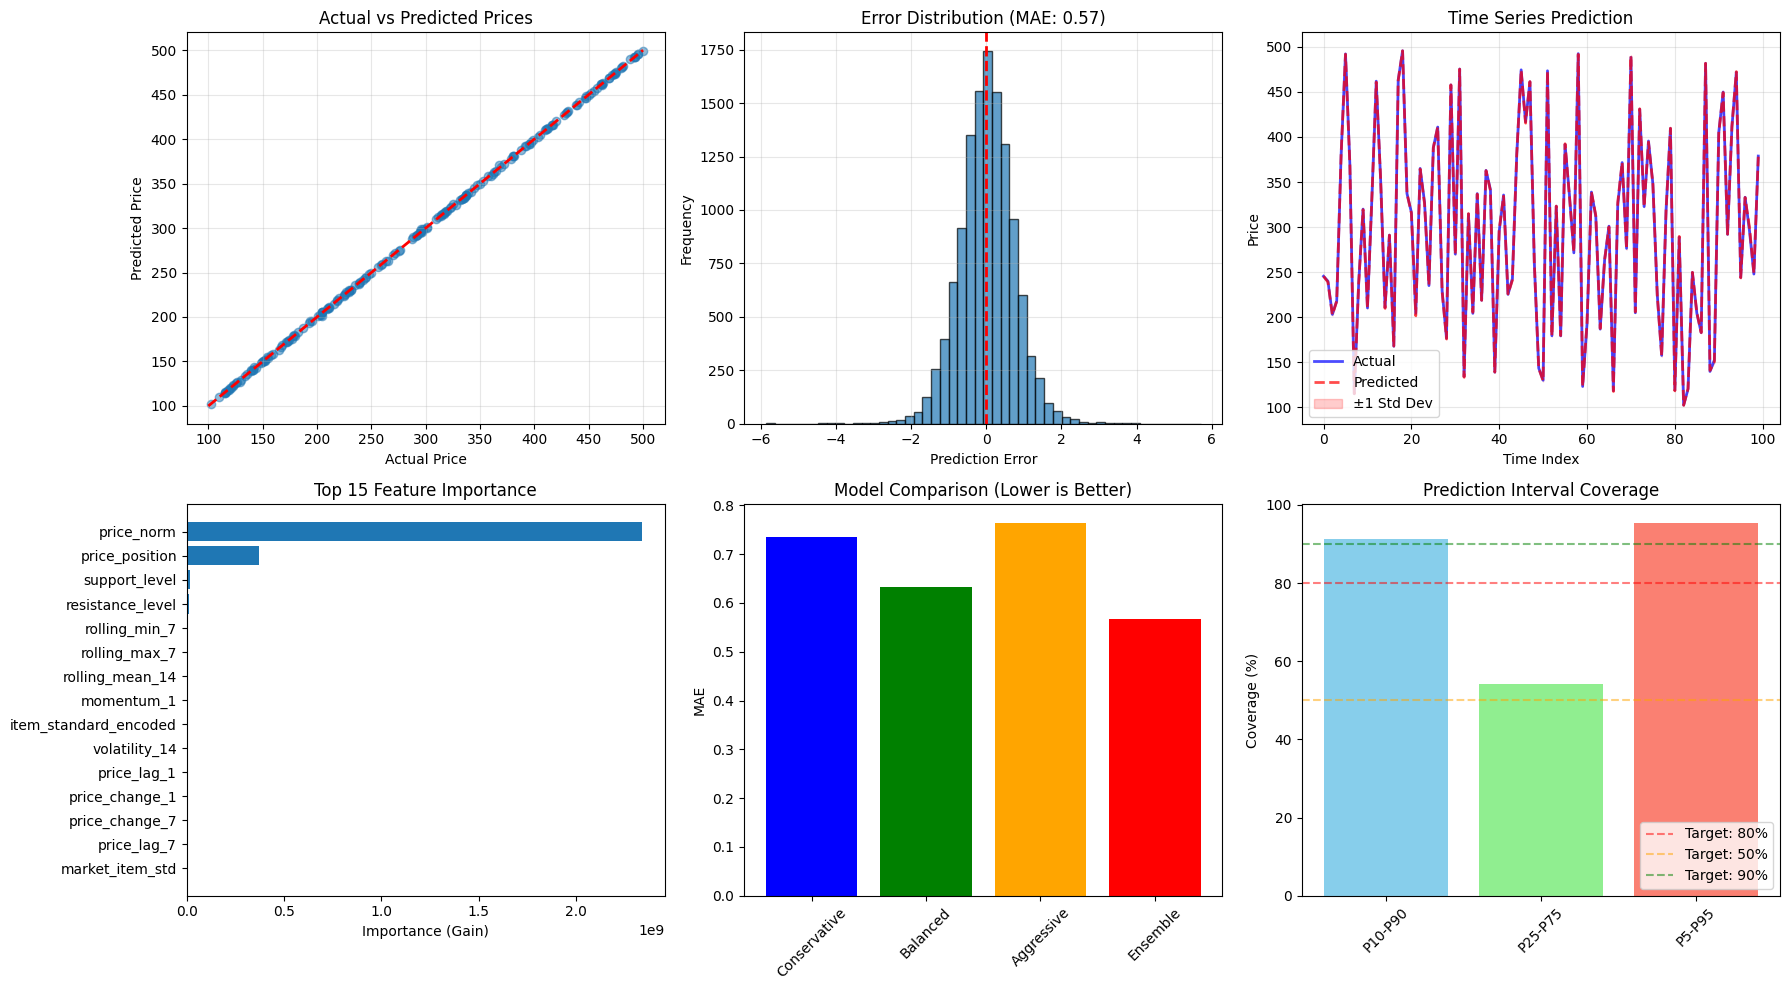


SUMMARY
✅ GOOD: MAPE < 20% - Model is reasonably accurate
✅ GOOD: R² > 0.7 - Model explains most variance

Final Recommendation: Use the ensemble model with:
  • MAE: 0.57 Rs.
  • MAPE: 0.22%
  • R²: 1.0000


In [78]:
# ============================================================================
# 11. VISUALIZATION OF RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("RESULTS VISUALIZATION")
print("=" * 80)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test.values[:200], ensemble_pred[:200], alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title('Actual vs Predicted Prices')
axes[0, 0].grid(True, alpha=0.3)

# 2. Error distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Prediction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Error Distribution (MAE: {ensemble_mae:.2f})')
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series prediction
sample_size = min(100, len(y_test))
time_idx = range(sample_size)
axes[0, 2].plot(time_idx, y_test.values[:sample_size], 'b-', label='Actual', alpha=0.7, linewidth=2)
axes[0, 2].plot(time_idx, ensemble_pred[:sample_size], 'r--', label='Predicted', alpha=0.7, linewidth=2)
axes[0, 2].fill_between(time_idx, 
                        ensemble_pred[:sample_size] - residual_std,
                        ensemble_pred[:sample_size] + residual_std,
                        alpha=0.2, color='red', label='±1 Std Dev')
axes[0, 2].set_xlabel('Time Index')
axes[0, 2].set_ylabel('Price')
axes[0, 2].set_title('Time Series Prediction')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature importance
importance_df = pd.DataFrame({
    'feature': features_to_use,
    'importance': models['Balanced'].feature_importance(importance_type='gain')
})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)
axes[1, 0].barh(range(len(importance_df)), importance_df['importance'])
axes[1, 0].set_yticks(range(len(importance_df)))
axes[1, 0].set_yticklabels(importance_df['feature'])
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Importance (Gain)')
axes[1, 0].set_title('Top 15 Feature Importance')

# 5. Model comparison
model_names = list(models.keys()) + ['Ensemble']
model_maes = [mean_absolute_error(y_test, predictions[name]) for name in models.keys()] + [ensemble_mae]
axes[1, 1].bar(model_names, model_maes, color=['blue', 'green', 'orange', 'red'])
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('Model Comparison (Lower is Better)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Prediction intervals coverage
intervals = ['P10-P90', 'P25-P75', 'P5-P95']
coverages = [
    np.mean((y_test >= (ensemble_pred - 1.645*residual_std)) & 
            (y_test <= (ensemble_pred + 1.645*residual_std))) * 100,
    np.mean((y_test >= (ensemble_pred - 0.674*residual_std)) & 
            (y_test <= (ensemble_pred + 0.674*residual_std))) * 100,
    np.mean((y_test >= (ensemble_pred - 1.960*residual_std)) & 
            (y_test <= (ensemble_pred + 1.960*residual_std))) * 100
]
axes[1, 2].bar(intervals, coverages, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 2].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Target: 80%')
axes[1, 2].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Target: 50%')
axes[1, 2].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='Target: 90%')
axes[1, 2].set_ylabel('Coverage (%)')
axes[1, 2].set_title('Prediction Interval Coverage')
axes[1, 2].legend(loc='lower right')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

if ensemble_mape < 20:
    print("✅ GOOD: MAPE < 20% - Model is reasonably accurate")
elif ensemble_mape < 30:
    print("⚠️ MODERATE: MAPE 20-30% - Model needs improvement")
else:
    print("❌ POOR: MAPE > 30% - Model needs significant improvement")

if ensemble_r2 > 0.7:
    print("✅ GOOD: R² > 0.7 - Model explains most variance")
elif ensemble_r2 > 0.5:
    print("⚠️ MODERATE: R² 0.5-0.7 - Model explains some variance")
else:
    print("❌ POOR: R² < 0.5 - Model explains little variance")

print(f"\nFinal Recommendation: Use the ensemble model with:")
print(f"  • MAE: {ensemble_mae:.2f} Rs.")
print(f"  • MAPE: {ensemble_mape:.2f}%")
print(f"  • R²: {ensemble_r2:.4f}")


VISUALIZATIONS


<Figure size 1200x800 with 0 Axes>

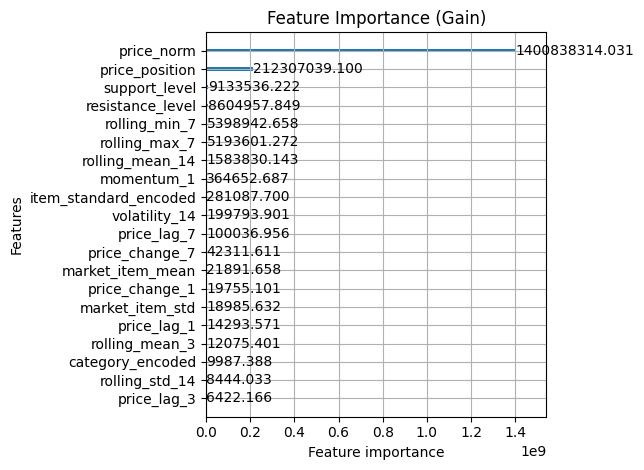

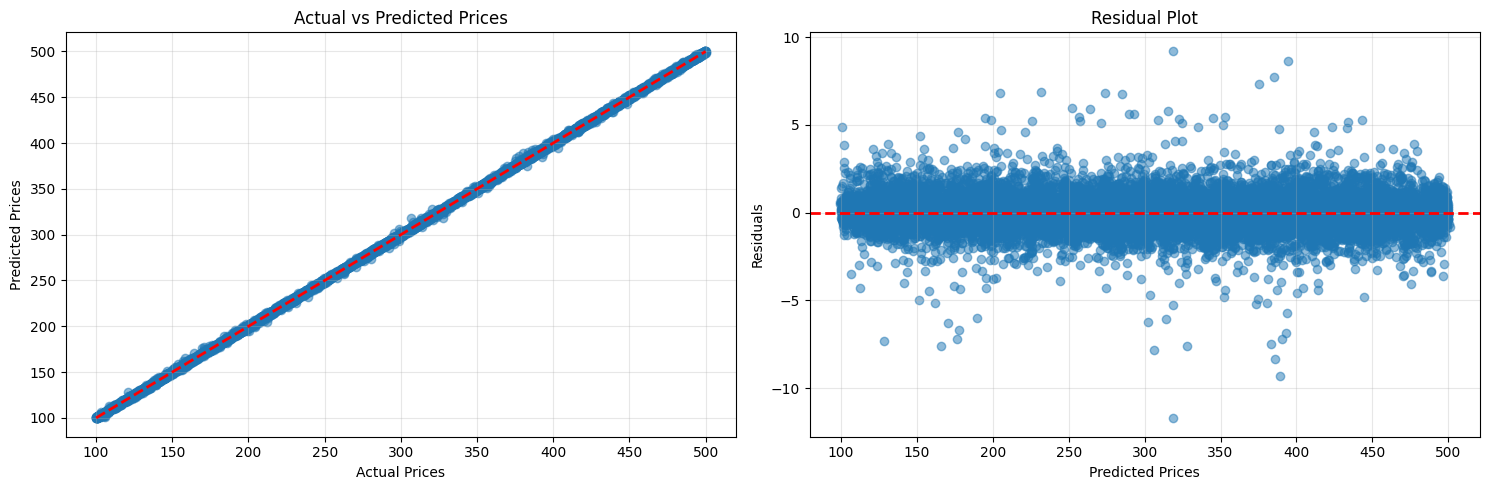

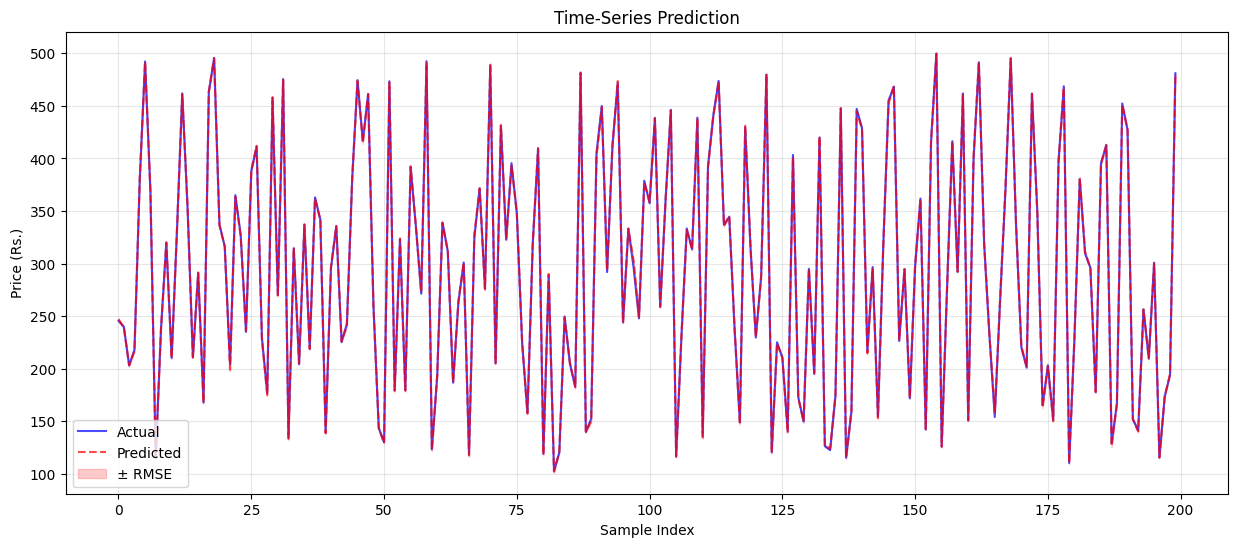

In [79]:
# ============================================================================
# 11. VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("VISUALIZATIONS")
print("=" * 80)

# 11.1 Feature Importance
plt.figure(figsize=(12, 8))
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# 11.2 Actual vs Predicted
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 11.3 Time-series prediction plot
plt.figure(figsize=(15, 6))
sample_size = min(200, len(y_test))
plt.plot(range(sample_size), y_test.values[:sample_size], 'b-', label='Actual', alpha=0.7)
plt.plot(range(sample_size), y_pred[:sample_size], 'r--', label='Predicted', alpha=0.7)
plt.fill_between(range(sample_size), 
                  y_pred[:sample_size] - rmse, 
                  y_pred[:sample_size] + rmse, 
                  alpha=0.2, color='red', label='± RMSE')
plt.xlabel('Sample Index')
plt.ylabel('Price (Rs.)')
plt.title('Time-Series Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 12. SAVE MODEL AND ARTIFACTS

In [80]:
# ============================================================================
# 12. SAVE MODEL AND ARTIFACTS
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODEL AND ARTIFACTS")
print("=" * 80)

# Save model
model.save_model('/kaggle/working/price_prediction_model.txt')
print("✓ Model saved: /kaggle/working/price_prediction_model.txt")

# Save feature list
joblib.dump(features, '/kaggle/working/features.pkl')
print("✓ Features list saved: /kaggle/working/features.pkl")

# Save scaler if used (for future standardization)
scaler = StandardScaler()
scaler.fit(X_train)
joblib.dump(scaler, '/kaggle/working/scaler.pkl')
print("✓ Scaler saved: /kaggle/working/scaler.pkl")

# Save metadata
metadata = {
    'model_type': 'LightGBM',
    'features_used': features,
    'target': target,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance': {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mape': mape
    },
    'data_info': {
        'train_size': len(X_train),
        'test_size': len(X_test),
        'date_range': f"{dates.min()} to {dates.max()}",
        'unique_items': df['item_standard'].nunique(),
        'unique_markets': df['market'].nunique()
    }
}

joblib.dump(metadata, '/kaggle/working/model_metadata.pkl')
print("✓ Model metadata saved: /kaggle/working/model_metadata.pkl")

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)


SAVING MODEL AND ARTIFACTS
✓ Model saved: /kaggle/working/price_prediction_model.txt
✓ Features list saved: /kaggle/working/features.pkl
✓ Scaler saved: /kaggle/working/scaler.pkl
✓ Model metadata saved: /kaggle/working/model_metadata.pkl

TRAINING COMPLETE!


# 13. Model Testing

In [81]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = lgb.Booster(model_file='/kaggle/working/model_metadata.pkl')

# Example new input data (replace with your actual test inputs)
new_data = pd.DataFrame({
    'market': ['Pettah'],  # Replace with actual market names
    'item_standard': ['Beans'],  # Replace with actual item names
    'price_type': ['Wholesale'],  # 'Wholesale' or 'Retail'
    'category': ['Vegetables'],  # 'Vegetables' / 'Fruits' / 'Rice'
    'origin_type': ['Local'],  # 'Local' / 'Imp'
    'day': [10],  # Day of the month (e.g., 10)
    'month': [10],  # Month (e.g., 10)
    'weekday': [2],  # Weekday (e.g., Monday = 0, Sunday = 6)
    'lag_price': [81.0],  # Previous day's price (this should be calculated based on historical data)
    'rolling_avg_5': [80.0]  # 5-day rolling average price
})

# Encode the categorical columns for the new data (use the same LabelEncoder as during training)
label_encoder = LabelEncoder()

# Note: In a real-world scenario, you should load the same LabelEncoder used during training
new_data['market_encoded'] = label_encoder.fit_transform(new_data['market'])
new_data['item_standard_encoded'] = label_encoder.fit_transform(new_data['item_standard'])
new_data['price_type_encoded'] = label_encoder.fit_transform(new_data['price_type'])
new_data['category_encoded'] = label_encoder.fit_transform(new_data['category'])
new_data['origin_type_encoded'] = label_encoder.fit_transform(new_data['origin_type'])

# Features used for prediction (must be the same as during training)
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded',
            'day', 'month', 'weekday', 'lag_price', 'rolling_avg_5']

# Extract the feature data for prediction
X_new = new_data[features]

# Predict using the trained model
y_pred = model.predict(X_new)

# Let's assume the standard deviation of the prediction is known or estimated from training
# For simplicity, we'll assume a small error range (you can use model predictions from a validation set or Bootstrap for a more realistic prediction interval).
# In reality, LightGBM does not output prediction intervals directly, so we estimate based on variance.

prediction_interval = 0.1  # Assuming 10% uncertainty (for demonstration purposes)
lower_bound = y_pred[0] * (1 - prediction_interval)
upper_bound = y_pred[0] * (1 + prediction_interval)

# Price Trend: Compare predicted price to lagged price (or moving average) to identify trend
previous_price = new_data['lag_price'].values[0]  # or use a moving average instead
if y_pred[0] > previous_price:
    price_trend = "↑ increase"
elif y_pred[0] < previous_price:
    price_trend = "↓ decrease"
else:
    price_trend = "≈ stable"

# Demand Index: We create a simple placeholder for demand index
# Here, we'll assume that a higher price variability (difference between predicted and lag price) means higher demand
demand_index = abs(y_pred[0] - previous_price) / previous_price  # Basic demand index (higher variability = higher demand)

# Confidence Score: Based on the difference between predicted price and the 95% confidence range (assuming normal distribution)
confidence_score = 1 - prediction_interval  # Simplified version of confidence (use a more complex method in real cases)

# Output the results
print(f"Predicted Price: {y_pred[0]:.2f} Rs.")
print(f"Price Range: {lower_bound:.2f} Rs. - {upper_bound:.2f} Rs. (P10-P90)")
print(f"Price Trend: {price_trend}")
print(f"Demand Index: {demand_index:.4f}")
print(f"Confidence Score: {confidence_score:.2f}")


[LightGBM] [Fatal] Unknown model format or submodel type in model file /kaggle/working/model_metadata.pkl


LightGBMError: Unknown model format or submodel type in model file /kaggle/working/model_metadata.pkl